# Lab 03 — Classification Metrics, Confusion Matrix, ROC-AUC

**Goal:** internalize precision, recall, F1, ROC-AUC, and the threshold trade-off.

Pair with `docs/04_classification.md` §0.2.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score, precision_recall_curve,
)

SEED = 42

## 2. Imbalanced setup

We deliberately downsample the positive class so accuracy becomes misleading.

In [2]:
data = load_breast_cancer()
X, y = data.data, data.target

pos_idx = np.where(y == 1)[0]
neg_idx = np.where(y == 0)[0]
rng = np.random.default_rng(SEED)
keep_pos = rng.choice(pos_idx, size=30, replace=False)
idx = np.concatenate([keep_pos, neg_idx])
X, y = X[idx], y[idx]
print('class balance:', np.bincount(y), '  positive rate:', y.mean().round(3))

class balance: [212  30]   positive rate: 0.124


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=SEED
)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

model = LogisticRegression(max_iter=2000, random_state=SEED).fit(X_train_s, y_train)
probs = model.predict_proba(X_test_s)[:, 1]
preds = (probs >= 0.5).astype(int)

print(f'accuracy at threshold 0.5: {accuracy_score(y_test, preds):.4f}')
print(f'majority-class accuracy  : {(1 - y_test.mean()):.4f}')

accuracy at threshold 0.5: 0.9589
majority-class accuracy  : 0.8767


Notice the model's accuracy barely beats the trivial "predict majority" baseline. Accuracy alone hides what's going on — go deeper.

## 3. Confusion matrix

In [4]:
cm = confusion_matrix(y_test, preds)
tn, fp, fn, tp = cm.ravel()
print('confusion matrix:')
print(cm)
print(f'TP = {tp}, FP = {fp}, FN = {fn}, TN = {tn}')
print()
print(f'precision = TP / (TP + FP) = {tp / (tp + fp):.4f}')
print(f'recall    = TP / (TP + FN) = {tp / (tp + fn):.4f}')
print(f'F1        = 2PR/(P+R)      = {2 * tp / (2 * tp + fp + fn):.4f}')

confusion matrix:
[[64  0]
 [ 3  6]]
TP = 6, FP = 0, FN = 3, TN = 64

precision = TP / (TP + FP) = 1.0000
recall    = TP / (TP + FN) = 0.6667
F1        = 2PR/(P+R)      = 0.8000


## 4. Threshold sweep

The 0.5 cutoff is just a default. Sweeping it trades precision against recall.

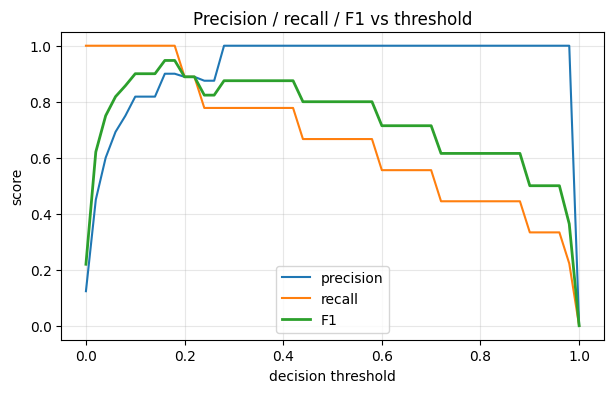

Best F1 = 0.9474 at threshold = 0.16


In [5]:
thresholds = np.linspace(0.0, 1.0, 51)
rows = []
for t in thresholds:
    p = (probs >= t).astype(int)
    rows.append({
        'threshold': t,
        'precision': precision_score(y_test, p, zero_division=0),
        'recall':    recall_score(y_test, p, zero_division=0),
        'f1':        f1_score(y_test, p, zero_division=0),
    })
df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df['threshold'], df['precision'], label='precision')
ax.plot(df['threshold'], df['recall'],    label='recall')
ax.plot(df['threshold'], df['f1'],        label='F1', linewidth=2)
ax.set_xlabel('decision threshold'); ax.set_ylabel('score')
ax.set_title('Precision / recall / F1 vs threshold')
ax.grid(True, alpha=0.3); ax.legend()
plt.show()

best = df.loc[df['f1'].idxmax()]
print(f"Best F1 = {best['f1']:.4f} at threshold = {best['threshold']:.2f}")

## 5. ROC curve and AUC

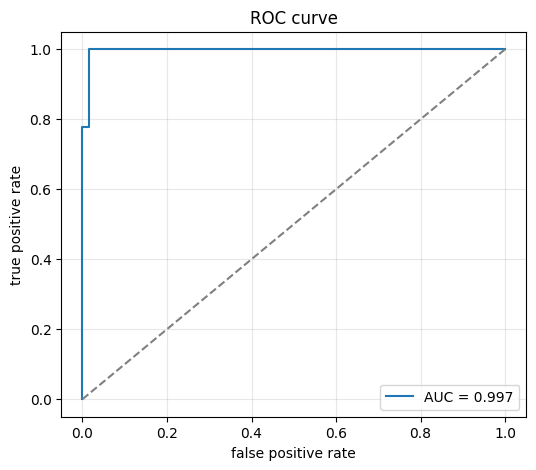

In [6]:
fpr, tpr, _ = roc_curve(y_test, probs)
auc = roc_auc_score(y_test, probs)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
ax.plot([0, 1], [0, 1], color='gray', ls='--')
ax.set_xlabel('false positive rate'); ax.set_ylabel('true positive rate')
ax.set_title('ROC curve')
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

## 6. Precision-recall curve

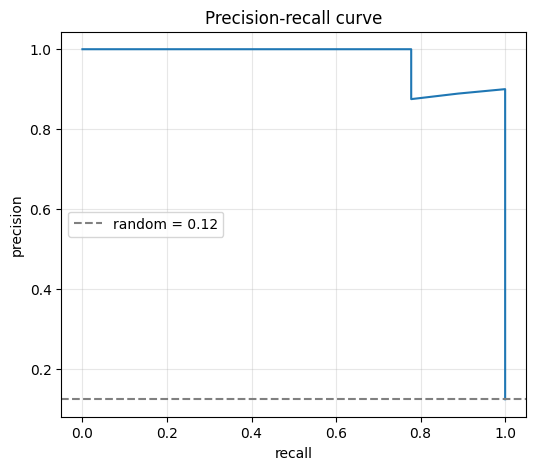

In [7]:
p_c, r_c, _ = precision_recall_curve(y_test, probs)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(r_c, p_c)
ax.axhline(y_test.mean(), color='gray', ls='--', label=f'random = {y_test.mean():.2f}')
ax.set_xlabel('recall'); ax.set_ylabel('precision')
ax.set_title('Precision-recall curve')
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

## 7. Summary

- Accuracy is misleading on imbalanced datasets.
- Precision-recall-F1 give a richer per-class view.
- The decision threshold is a knob, not a constant. Sweep it.
- ROC-AUC is threshold-agnostic; PR-AUC is preferable when positives are very rare.
- Always pair a metric with the class proportion it was measured on.